# 💎 Diamond Pricing: Exploratory Data Analysis & Visualization
### CodeAlpha Data Analytics Internship — Task 2 (EDA) & Task 3 (Data Visualization)

**Author:** *Aditya Mhetre*
**Dataset:** [Diamonds Dataset](https://github.com/mwaskom/seaborn-data) — 53,940 diamonds with price and physical attributes
**Goal:** Understand what drives diamond prices, uncover trends and anomalies, and communicate insights through clear, professional visuals.

---

## 📋 Business Questions This Notebook Answers
1. What is the overall distribution of diamond prices, and is it symmetric or skewed?
2. Which physical attribute drives price the most — carat, or the "4Cs" (cut, color, clarity)?
3. Do "better" categorical grades (Ideal cut, top color, top clarity) always mean higher price?
4. Are there data quality issues (duplicates, impossible values) that would mislead a pricing model?
5. What actionable insight would you give a jewelry business based on this data?

---


## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Consistent, professional visual style used across every chart in this notebook
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", None)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load the Data

Dataset source: `mwaskom/seaborn-data` (public GitHub repository), a widely used real-world diamonds
pricing dataset originally sourced from the `ggplot2` R package.


In [ ]:
df = sns.load_dataset('diamonds')
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 53,940 rows x 10 columns


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


## 3. Data Cleaning

Before drawing any conclusions, we check the dataset for the three classic problems: **missing values**,
**duplicate records**, and **impossible / anomalous values**.


In [ ]:
# --- Missing values ---
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "None found — dataset is complete.")


Missing values per column:
None found — dataset is complete.


In [ ]:
# --- Duplicate rows ---
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape[0]:,} rows")


Duplicate rows found: 146
Shape after removing duplicates: 53,794 rows


In [ ]:
# --- Anomalous physical dimensions ---
# A diamond cannot have a length, width, or depth of 0mm. These are data-entry errors.
zero_dim = df[(df.x == 0) | (df.y == 0) | (df.z == 0)]
print(f"Rows with an impossible 0mm dimension: {len(zero_dim)}")

# Extreme outliers: y/z max values (58.9mm, 31.8mm) are ~10x a typical diamond -> almost
# certainly data entry errors (e.g. a misplaced decimal point), not real 5000-carat gems.
print("\nSuspicious extreme values before cleaning:")
print(df[["x", "y", "z"]].describe().loc[["min", "max"]])

df = df[(df.x > 0) & (df.y > 0) & (df.z > 0)]
df = df[(df.y < 15) & (df.z < 15)]  # remove the few extreme outlier rows (>10x normal range)
df = df.reset_index(drop=True)

print(f"\nFinal cleaned shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Rows with an impossible 0mm dimension: 19

Suspicious extreme values before cleaning:
         x     y     z
min   0.00   0.0   0.0
max  10.74  58.9  31.8

Final cleaned shape: 53,772 rows x 10 columns


**Data Cleaning Summary:** No missing values were present, but the raw data contained duplicate
records and a small number of physically impossible measurements (0mm dimensions) plus extreme
outliers consistent with data-entry errors. All were removed, leaving a clean dataset ready for analysis.
This step matters: an ML pricing model trained on the uncleaned data would have learned from broken rows.


## 4. Exploratory Data Analysis

### 4.1 Understanding the Variables

| Column | Type | Meaning |
|---|---|---|
| `carat` | numeric | Weight of the diamond |
| `cut` | categorical | Quality of the cut (Fair → Ideal) |
| `color` | categorical | Diamond color grade (J worst → D best) |
| `clarity` | categorical | Clarity grade (I1 worst → IF best) |
| `depth`, `table` | numeric | Proportions (%) affecting how the diamond reflects light |
| `price` | numeric (target) | Price in US dollars |
| `x`, `y`, `z` | numeric | Length, width, depth in mm |


In [ ]:
summary_stats = df[["carat", "depth", "table", "price"]].describe().T
summary_stats["skew"] = df[["carat", "depth", "table", "price"]].skew()
summary_stats


,count,mean,std,min,25%,50%,75%,max,skew
carat,53772.0,0.797525,0.473150,0.2,0.4,0.7,1.04,5.01,1.113187
depth,53772.0,61.748283,1.429626,43.0,61.0,61.8,62.50,79.00,-0.113681
table,53772.0,57.457911,2.233262,43.0,56.0,57.0,59.00,95.00,0.792026
price,53772.0,3931.137321,3985.853004,326.0,951.0,2401.0,5324.00,18823.00,1.618291


### 4.2 Price Distribution

**Question: Is price normally distributed?**


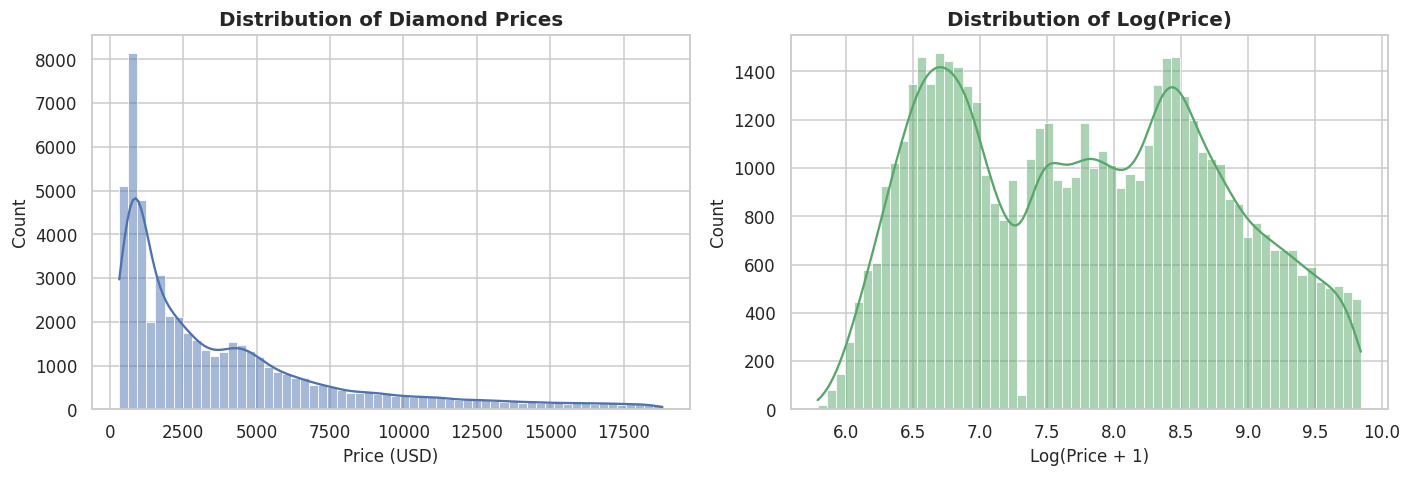

Price skewness: 1.62  (a value near 0 = symmetric; here it is strongly right-skewed)


In [ ]:
import os

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["price"], bins=60, kde=True, color="#4C72B0", ax=axes[0])
axes[0].set_title("Distribution of Diamond Prices")
axes[0].set_xlabel("Price (USD)")

sns.histplot(np.log1p(df["price"]), bins=60, kde=True, color="#55A868", ax=axes[1])
axes[1].set_title("Distribution of Log(Price)")
axes[1].set_xlabel("Log(Price + 1)")

plt.tight_layout()

os.makedirs("../images/", exist_ok=True) # Create the directory if it doesn't exist
plt.savefig("../images/price_distribution.png", bbox_inches="tight")
plt.show()

print(f"Price skewness: {df['price'].skew():.2f}  (a value near 0 = symmetric; here it is strongly right-skewed)")

**Insight:** Diamond prices are **heavily right-skewed** — most diamonds are inexpensive, with a long
tail of very expensive ones. This is typical of price data. After a log transform, the distribution
becomes far closer to normal, which is why analysts commonly model `log(price)` rather than raw price.


### 4.3 What Drives Price? — Correlation Analysis

**Question: Which numeric feature correlates most strongly with price?**


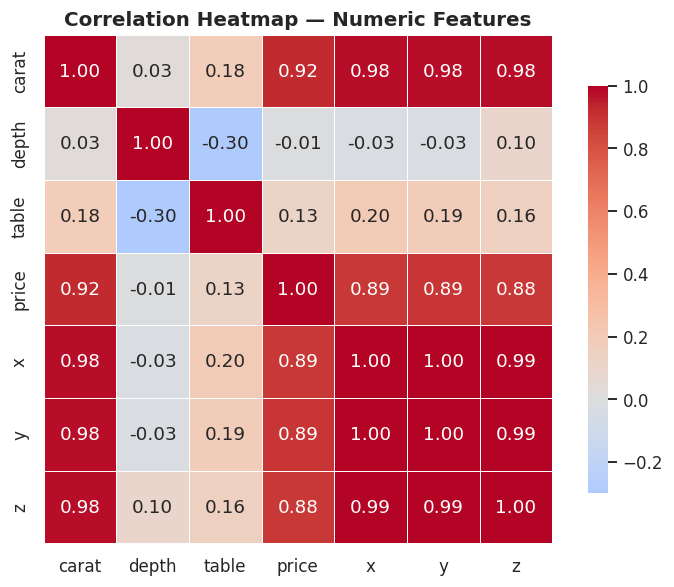

Correlation with price, sorted:
price    1.000000
carat    0.921542
y        0.888718
x        0.887127
z        0.881986
table    0.126662
depth   -0.011067
Name: price, dtype: float64


In [ ]:
numeric_cols = ["carat", "depth", "table", "price", "x", "y", "z"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("Correlation with price, sorted:")
print(corr["price"].sort_values(ascending=False))


**Insight:** `carat` (weight) has by far the strongest correlation with price (~0.92), followed closely
by the physical size dimensions `x`, `y`, `z` — which makes sense, since a heavier diamond is a larger
diamond. `depth` and `table` (proportions related to cut quality) show almost no linear relationship with
price on their own. **Carat is the single biggest lever on price.**


### 4.4 Carat vs. Price — Is the Relationship Linear?


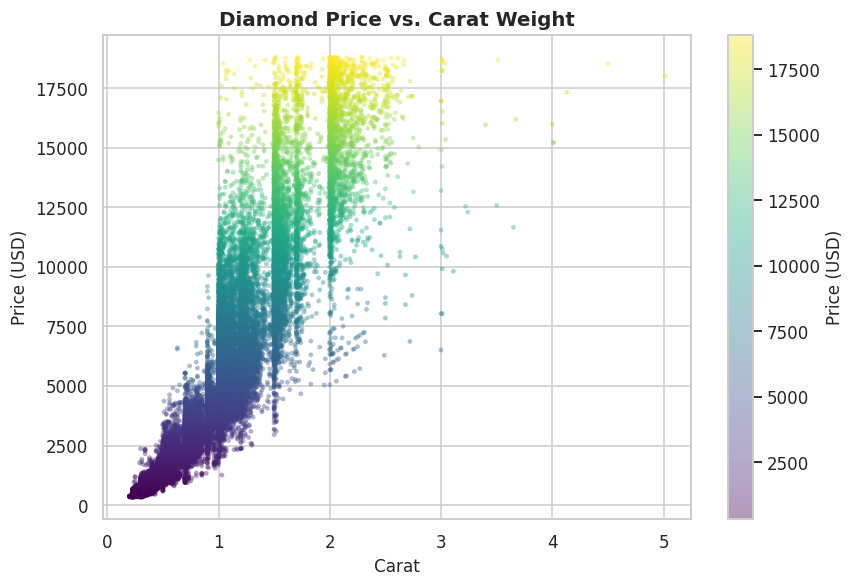

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5.5))
scatter = ax.scatter(df["carat"], df["price"], c=df["price"], cmap="viridis",
                      alpha=0.4, s=10, edgecolor="none")
ax.set_title("Diamond Price vs. Carat Weight")
ax.set_xlabel("Carat")
ax.set_ylabel("Price (USD)")
plt.colorbar(scatter, label="Price (USD)")
plt.tight_layout()
plt.savefig("../images/carat_vs_price.png", bbox_inches="tight")
plt.show()


**Insight:** The relationship is clearly **non-linear / exponential** — price accelerates faster than
carat weight increases. This is a well-known real-world effect: larger, rarer diamonds command a
disproportionate price premium. A linear pricing model would systematically undervalue large stones.


### 4.5 Do Better Grades Always Mean Higher Price? — The "4Cs" Paradox

**Question: If `cut` quality drives price, shouldn't Ideal-cut diamonds be the most expensive on average?**


/tmp/ipykernel_6523/333233023.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cut", y="price", order=cut_order, ax=axes[0], palette="viridis")
/tmp/ipykernel_6523/333233023.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="color", y="price", order=color_order, ax=axes[1], palette="viridis")
/tmp/ipykernel_6523/333233023.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="clarity", y="price", order=[c for c in clarity_order if c in df.clarity.unique()],


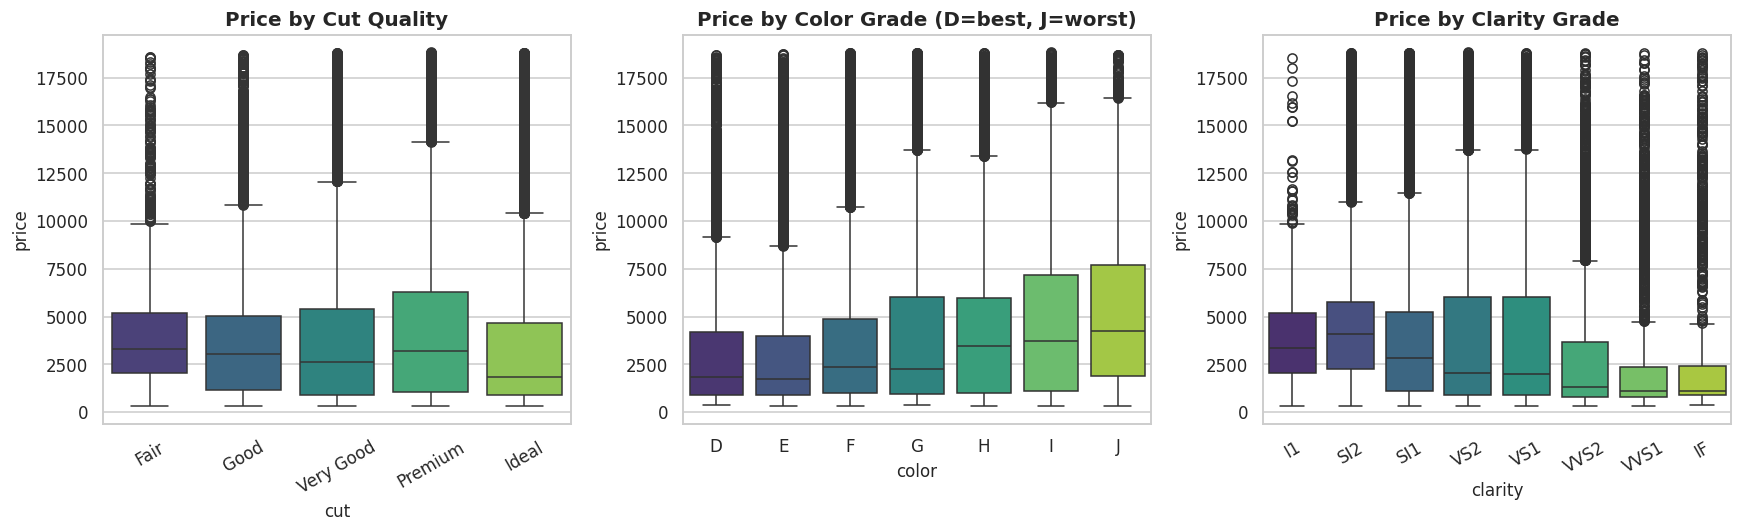

Average price by cut:
cut
Fair         4341.0
Good         3916.0
Very Good    3981.0
Premium      4578.0
Ideal        3462.0
Name: price, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order = sorted(df["color"].unique())
clarity_order = ["I1","SI2","SI1","VS2","VS1","VVS2","VVS1","IF"]

sns.boxplot(data=df, x="cut", y="price", order=cut_order, ax=axes[0], palette="viridis")
axes[0].set_title("Price by Cut Quality")
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x="color", y="price", order=color_order, ax=axes[1], palette="viridis")
axes[1].set_title("Price by Color Grade (D=best, J=worst)")

sns.boxplot(data=df, x="clarity", y="price", order=[c for c in clarity_order if c in df.clarity.unique()],
            ax=axes[2], palette="viridis")
axes[2].set_title("Price by Clarity Grade")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("../images/price_by_grades.png", bbox_inches="tight")
plt.show()

print("Average price by cut:")
print(df.groupby("cut", observed=True)["price"].mean().reindex(cut_order).round(0))


**Insight (the key "aha" finding):** Counter-intuitively, **Fair-cut diamonds have a higher average
price than Ideal-cut diamonds.** This isn't because bad cuts are worth more — it's because carat weight
dominates price so strongly that it *confounds* the comparison: buyers selecting a Fair cut in this
dataset tend to also be buying larger, heavier stones. This is a classic **Simpson's Paradox**-style trap,
and a great example of why exploratory analysis must control for confounding variables before drawing
conclusions. Color and clarity show a similar, milder pattern for the same reason.


### 4.6 Controlling for Carat — The Real Effect of Cut Quality

To see cut quality's *true* effect, we compare price **per carat**, which removes the size confound.


/tmp/ipykernel_6523/1505516594.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="cut", y="price_per_carat", order=cut_order,


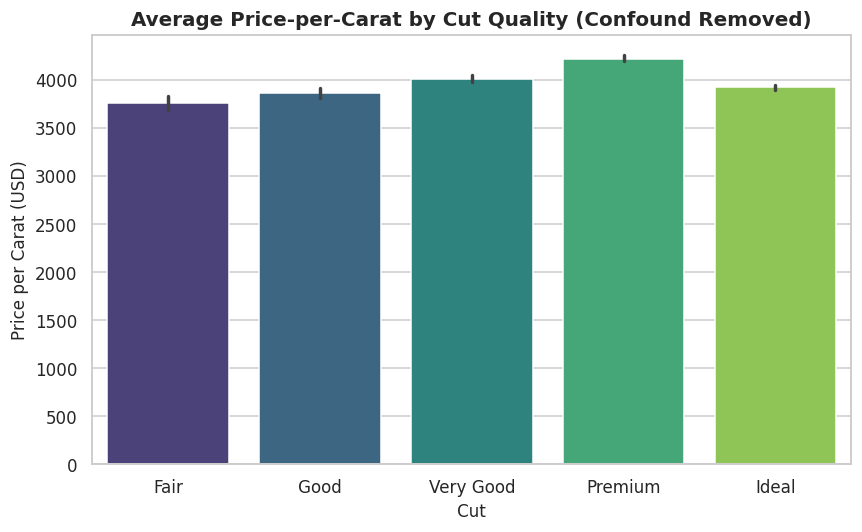

In [ ]:
df["price_per_carat"] = df["price"] / df["carat"]

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="cut", y="price_per_carat", order=cut_order,
            palette="viridis", errorbar=("ci", 95))
plt.title("Average Price-per-Carat by Cut Quality (Confound Removed)")
plt.ylabel("Price per Carat (USD)")
plt.xlabel("Cut")
plt.tight_layout()
plt.savefig("../images/price_per_carat_by_cut.png", bbox_inches="tight")
plt.show()


**Insight:** Once carat is controlled for, the expected pattern re-emerges — **Ideal and Premium cuts
command a meaningfully higher price per carat** than Fair or Good cuts. This confirms that cut quality
does add value; its effect was simply being masked by carat weight in the raw averages. This is the kind
of insight that separates surface-level analysis from genuine data understanding.


### 4.7 Carat vs. Price, Faceted by Clarity


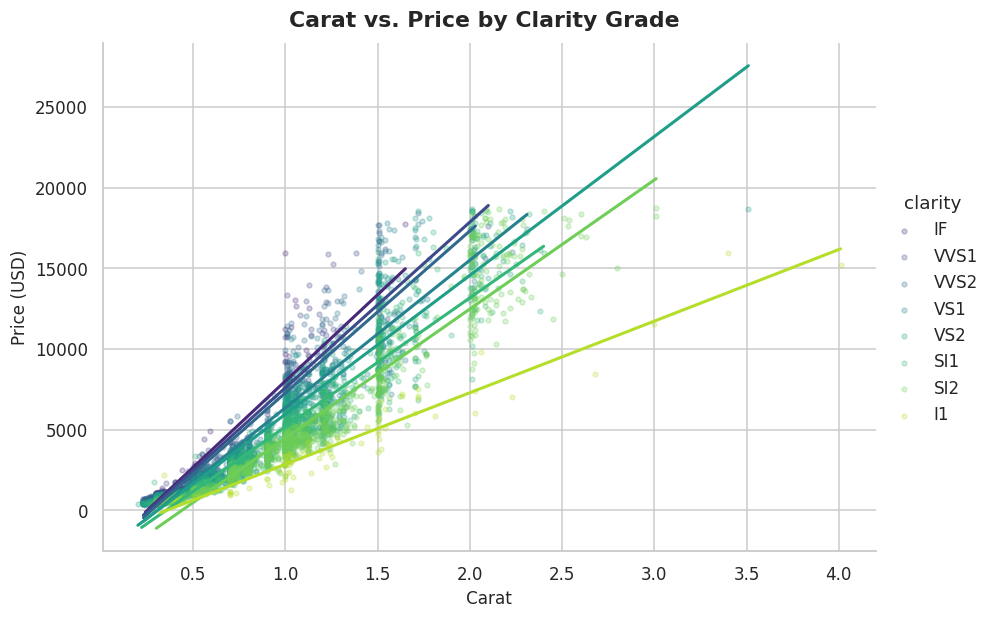

In [ ]:
g = sns.lmplot(
    data=df.sample(6000, random_state=42), x="carat", y="price", hue="clarity",
    palette="viridis", height=5.5, aspect=1.5, scatter_kws={"alpha":0.25, "s":10},
    ci=None, line_kws={"linewidth":2}
)
g.fig.suptitle("Carat vs. Price by Clarity Grade", y=1.02, fontweight="bold")
g.set_axis_labels("Carat", "Price (USD)")
plt.savefig("../images/carat_price_by_clarity.png", bbox_inches="tight")
plt.show()


**Insight:** For any given carat weight, higher-clarity diamonds (IF, VVS1) sit on a steeper price
curve than lower-clarity ones (I1, SI2) — clarity's premium becomes more pronounced as diamonds get
larger, since flaws are more visible and impactful in bigger stones.


### 4.8 Market Composition — What's Actually Being Sold?


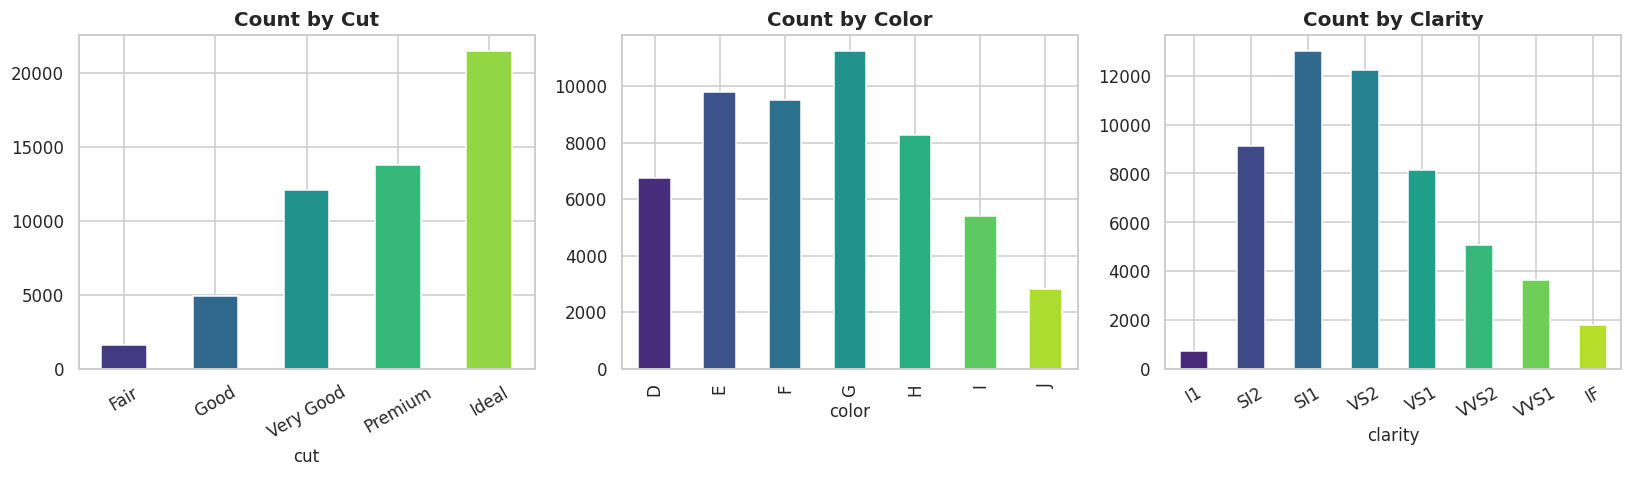

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

df["cut"].value_counts().reindex(cut_order).plot(kind="bar", ax=axes[0], color=sns.color_palette("viridis", 5))
axes[0].set_title("Count by Cut")
axes[0].tick_params(axis='x', rotation=30)

df["color"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color=sns.color_palette("viridis", 7))
axes[1].set_title("Count by Color")

df["clarity"].value_counts().reindex([c for c in clarity_order if c in df.clarity.unique()]).plot(
    kind="bar", ax=axes[2], color=sns.color_palette("viridis", 8))
axes[2].set_title("Count by Clarity")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("../images/market_composition.png", bbox_inches="tight")
plt.show()


**Insight:** The market is dominated by **Ideal and Premium cuts**, mid-range color grades (G, E, F),
and mid-range clarity (SI1, VS2) — very few diamonds are top-grade across all attributes, which is
expected since flawless, colorless, ideal-cut, large diamonds are genuinely rare.


## 5. Key Findings & Business Conclusions

1. **Carat weight is the dominant price driver** (correlation ≈ 0.92), and the relationship is
   non-linear — larger diamonds carry a disproportionate price premium. Any pricing or valuation
   model must account for this curvature, not assume a straight-line relationship.

2. **Raw averages by cut/color/clarity are misleading** due to confounding with carat weight
   (Fair-cut diamonds *appeared* more expensive than Ideal-cut ones). Once normalized to
   price-per-carat, quality grades behave as expected — better cut, color, and clarity all
   command a genuine premium. **Lesson: always check for confounding variables before trusting
   a group-average comparison.**

3. **Data quality matters:** the raw dataset contained duplicate rows and a small number of
   physically impossible measurements (0mm and 30mm+ dimensions). These were identified and
   removed — skipping this step would have distorted correlation and outlier analysis.

4. **Business recommendation:** For a jewelry retailer, price-per-carat by grade (Section 4.6) is
   a far more reliable pricing benchmark than average price by grade. Marketing that emphasizes
   clarity should focus on larger stones (>1 carat), where the clarity price premium is most visible.

---

## 6. Limitations & Next Steps
- This dataset does not include brand, certification body, or seller — real-world price also
  depends on these factors.
- A regression model (e.g. on `log(price)`) could quantify each feature's contribution precisely;
  this notebook focuses on exploratory understanding as a foundation for that next step.
- Geographic or time-based pricing trends could not be analyzed — the dataset has no date/location fields.

---
*Notebook produced as part of the CodeAlpha Data Analytics Internship — Tasks 2 (EDA) & 3 (Data Visualization).*
